### Bibliotecas

In [1]:
import pandas as pd
import numpy as np

import os
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error
from scipy.stats import randint, uniform

In [ ]:
# Definir diretório
os.chdir('')

# Exibir toas as linhas e colunas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Evitar avisos
warnings.filterwarnings('ignore')

### Importandos os dados

In [3]:
# Treino
train = pd.read_csv('train.csv')

# Teste
test = pd.read_csv('test.csv')

# Submissão
sample_submission = pd.read_csv('sample_submission.csv')

### Análise dos dados

In [4]:
# Dimenssionalidade do conjunto de treino
train.shape

(630000, 13)

In [5]:
# Primeiras observações
train.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [6]:
# Resumo do conjunto de treino
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [7]:
# Verificando se há dados faltantes
test.isna().sum()

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
dtype: int64

In [8]:
# Resumo estatístico (dos atributos numéricos) do conjunto de treino
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.000,157499.75,314999.5,472499.25,629999.00
age,630000.0,20.545821,2.260238,17.000,19.00,21.0,23.00,24.00
study_hours,630000.0,4.002337,2.359880,0.080,1.97,4.0,6.05,7.91
class_attendance,630000.0,71.987261,17.430098,40.600,57.00,72.6,87.20,99.40
sleep_hours,630000.0,7.072758,1.744811,4.100,5.60,7.1,8.60,9.90
exam_score,630000.0,62.506672,18.916884,19.599,48.80,62.6,76.30,100.00


In [9]:
# Número de classes únicas por colunas não numéricas
classes_unicas = (train.select_dtypes(exclude='number').nunique().sort_values(ascending=False))
print(classes_unicas)

course             7
study_method       5
gender             3
sleep_quality      3
facility_rating    3
exam_difficulty    3
internet_access    2
dtype: int64


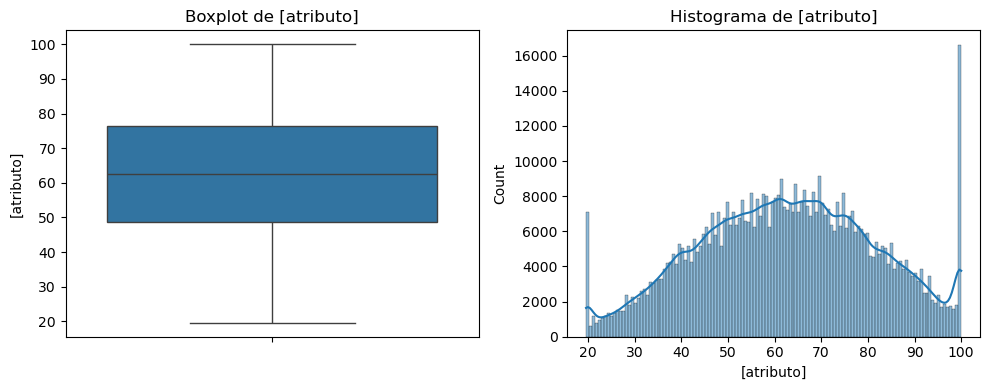

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Boxplot
sns.boxplot(data=train, y='exam_score', ax=axes[0])
axes[0].set_title('Boxplot de [atributo]')
axes[0].set_ylabel('[atributo]')

# Histograma
sns.histplot(data=train, x='exam_score', kde=True, ax=axes[1])
axes[1].set_title('Histograma de [atributo]')
axes[1].set_xlabel('[atributo]')

plt.tight_layout()
plt.show()

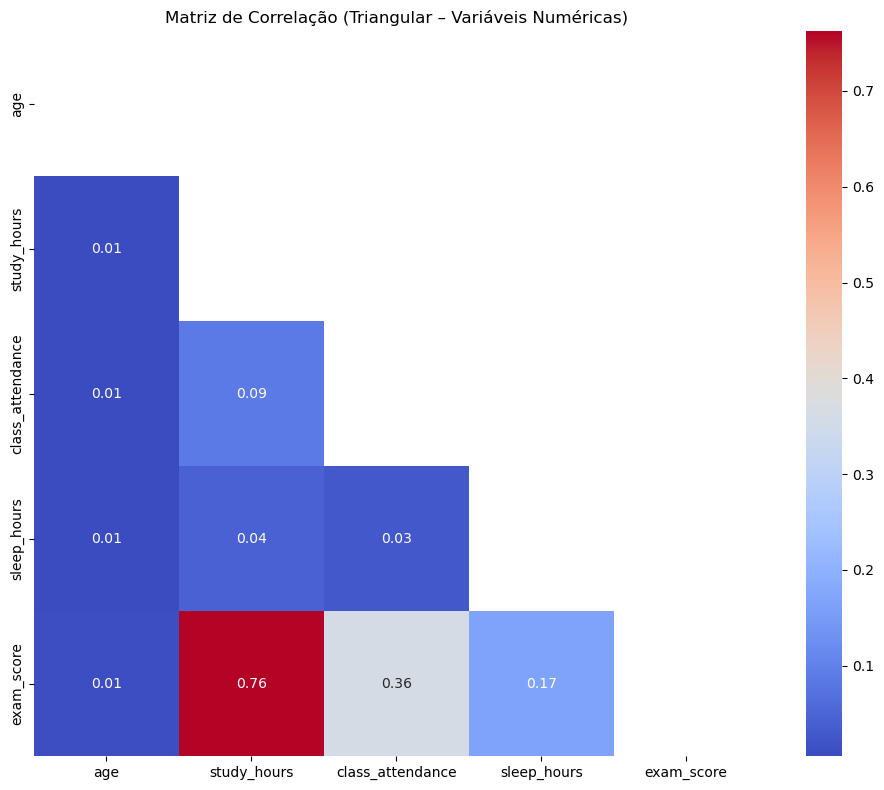

In [11]:
# Correlação

# Selecionar apenas variáveis numéricas
train_num = train.select_dtypes(include='number')

# Remover id, se existir
train_num = train_num.drop(columns=['id'], errors='ignore')

# Matriz de correlação
corr = train_num.corr()

# Criar máscara para o triângulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Matriz de Correlação (Triangular – Variáveis Numéricas)")
plt.tight_layout()
plt.show()

### Separar em treino e validação

In [12]:
# Remover a coluna ID
train = train.drop(columns=['id'])

In [13]:
# Separando os dados
from sklearn.model_selection import train_test_split

target = "exam_score"
X = train.drop(columns=[target])
y = train[target]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, # Conjunto de validação
                                                      random_state=42, 
                                                      shuffle=True)

In [14]:
# Primeiras observações de X_train
X_train.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
625149,20,other,b.com,0.84,79.0,yes,9.9,good,mixed,low,hard
276435,19,female,b.com,3.35,94.2,yes,6.0,good,group study,medium,moderate
43949,18,female,ba,2.20,87.5,yes,6.8,good,online videos,high,easy
280523,18,male,bca,3.10,64.0,yes,7.6,average,self-study,medium,moderate
619977,22,female,diploma,1.44,56.2,yes,5.5,average,online videos,medium,hard


### Encoding

In [15]:
# Número de classes únicas por colunas não numéricas
classes_unicas = (X_train.select_dtypes(exclude='number').nunique().sort_values(ascending=False))
print(classes_unicas)

course             7
study_method       5
gender             3
sleep_quality      3
facility_rating    3
exam_difficulty    3
internet_access    2
dtype: int64


#### OrdinalEncoder

In [16]:
# colunas categóricas
cat_cols = [
    'course',
    'study_method',
    'gender',
    'sleep_quality',
    'facility_rating',
    'exam_difficulty',
    'internet_access'
]

# encoder: aprende no treino e lida com categorias novas
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

In [17]:
# Aprende em treino e aplica na validação
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_valid[cat_cols] = encoder.transform(X_valid[cat_cols])

### Padronizar

In [18]:
from sklearn.preprocessing import MinMaxScaler

# Criar o scaler
scaler = MinMaxScaler()

# Ajustar apenas no treino e transformar
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar a mesma transformação no conjunto de validação
X_valid_scaled = scaler.transform(X_valid)

# Transformar de volta em DataFrame mantendo os nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_valid_scaled = pd.DataFrame(X_valid_scaled, columns=X_valid.columns)

### Previsão

##### DecisionTree

In [88]:
from sklearn.tree import DecisionTreeRegressor

# Modelo base
dt = DecisionTreeRegressor(
    random_state=42
)

# Espaço de hiperparâmetros
param_dist = {
    "max_depth": randint(2, 30),                 # profundidade da árvore
    "min_samples_split": randint(2, 50),         # mínimo de observações para split
    "min_samples_leaf": randint(1, 30),          # mínimo em cada folha
    "max_features": uniform(0.3, 0.7)            # fração de variáveis (0.3 a 1.0)
}

# Validação cruzada
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# RandomSearchCV
random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    verbose=3,
    n_jobs=2,
    random_state=42
)

# Treinamento
random_search.fit(X_train_scaled, y_train)

print("Melhores parâmetros:", random_search.best_params_)
print("Melhor RMSE CV:", -random_search.best_score_)

# Avaliação no conjunto de validação
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_valid_scaled)
rmse_val = np.sqrt(mean_squared_error(y_valid, y_pred))

print("Validation RMSE:", f"{rmse_val:.5f}")

# Fitting 5 folds for each of 50 candidates, totalling 250 fits
# Melhores parâmetros: {'max_depth': 14, 'max_features': 0.6778887639111711, 'min_samples_leaf': 29, 'min_samples_split': 37}
# Melhor RMSE CV: 9.254781013074439
# Validation RMSE: 9.19674

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Melhores parâmetros: {'max_depth': 14, 'max_features': 0.6778887639111711, 'min_samples_leaf': 29, 'min_samples_split': 37}
Melhor RMSE CV: 9.254781013074439
Validation RMSE: 9.19674


##### XGBoost

In [66]:
from xgboost import XGBRegressor

# Modelo base 
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",        # mais rápido e estável
    eval_metric="rmse"
)

# Espaço de hiperparâmetros
param_dist = {
    "n_estimators": randint(200, 1000),        # número de árvores
    "max_depth": randint(3, 10),               # profundidade das árvores
    "learning_rate": uniform(0.01, 0.09),      # 0.01 a 0.10
    "subsample": uniform(0.6, 0.4),            # 0.6 a 1.0
    "colsample_bytree": uniform(0.6, 0.4),     # fração de variáveis
    "min_child_weight": randint(1, 10),        # regularização nas folhas
    "gamma": uniform(0, 5)                     # penalização para splits
}

# Validação cruzada
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    verbose=3,
    n_jobs=2,
    random_state=42
)

# Treinamento
random_search.fit(X_train_scaled, y_train)

print("Melhores parâmetros:", random_search.best_params_)
print("Melhor RMSE CV:", -random_search.best_score_)

# Avaliação no conjunto de validação
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_valid_scaled)
rmse_val = np.sqrt(mean_squared_error(y_valid, y_pred))

print("Validation RMSE:", f"{rmse_val:.5f}")

# Fitting 5 folds for each of 50 candidates, totalling 250 fits
# Melhores parâmetros: {'colsample_bytree': 0.7323592099410596, 'gamma': 0.3177917514301182, 'learning_rate': 0.037988408954409594, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 883, 'subsample': 0.8550229885420852}
# Melhor RMSE CV: 8.761137880994314
# Validation RMSE: 8.74451

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Melhores parâmetros: {'colsample_bytree': 0.7323592099410596, 'gamma': 0.3177917514301182, 'learning_rate': 0.037988408954409594, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 883, 'subsample': 0.8550229885420852}
Melhor RMSE CV: 8.761137880994314
Validation RMSE: 8.74451


### Teste

In [89]:
# Removendo a coluna id do X_test (mas vamos precisar dela para o submission)
ids = test["id"].copy()
X_test = test.drop(columns=["id"])

In [90]:
# OrdinalEncoder
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [91]:
# Padronização
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [92]:
#X_valid_scaled.columns == X_test_scaled.columns

In [93]:
# Previsão
y_test_pred = best_model.predict(X_test_scaled)

### Submissão

In [94]:
# Criar DataFrame de submissão
submission = pd.DataFrame({
    "id": ids,         # ids do conjunto de teste
    "exam_score": y_test_pred   # substituir "y" pelo nome da target da competição
})

# Salvar em CSV
submission.to_csv("decision_tree.csv", index=False)